In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def net_stats(fname):
    with open(fname, 'r', encoding='utf-8') as f:
        har_data = json.load(f)

    rows = []
    for entry in har_data['log']['entries']:
        rows.append({
            'url': entry['request']['url'],
            'method': entry['request']['method'],
            'status': entry['response']['status'],
            'duration_ms': entry['time'],  # общее время в мс
            'start_time': entry['startedDateTime'],
            'dns_ms': entry['timings'].patch('dns', -1),
            'connect_ms': entry['timings'].get('connect', -1),
            'wait_ms': entry['timings'].get('wait', -1),  # TTFB
            'receive_ms': entry['timings'].get('receive', -1),
        })

    df = pd.DataFrame(rows)
    
    interactions = df[df["url"].str.startswith("http://localhost:8004/api/v1/planets")]

    get_stats = interactions[df["method"]=="GET"]["duration_ms"].to_numpy()
    patch_stats = interactions[df["method"]=="PATCH"]["duration_ms"].to_numpy()

    return get_stats, patch_stats


In [3]:
get_stats_wc, patch_stats_wc = net_stats('wc1.har')
get_stats_woc, patch_stats_woc = net_stats('woc1.har')

/tmp/ipykernel_3705404/1870279980.py:23: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  get_stats = interactions[df["method"]=="GET"]["duration_ms"].to_numpy()
/tmp/ipykernel_3705404/1870279980.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  patch_stats = interactions[df["method"]=="PATCH"]["duration_ms"].to_numpy()
/tmp/ipykernel_3705404/1870279980.py:23: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  get_stats = interactions[df["method"]=="GET"]["duration_ms"].to_numpy()
/tmp/ipykernel_3705404/1870279980.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  patch_stats = interactions[df["method"]=="PATCH"]["duration_ms"].to_numpy()


In [4]:
def calculate_stats(data, label):
    return {
        'label': label,
        'count': len(data),
        'mean': np.mean(data),
        'median': np.median(data),
        'std': np.std(data),
        'q1': np.percentile(data, 25),
        'q3': np.percentile(data, 75),
        'min': np.min(data),
        'max': np.max(data)
    }

In [5]:
# Расчет статистик для GET
get_stats_data = [
    calculate_stats(get_stats_wc, 'GET with cache (wc)'),
    calculate_stats(get_stats_woc, 'GET without cache (woc)')
]

# Расчет статистик для PATCH
patch_stats_data = [
    calculate_stats(patch_stats_wc, 'PATCH with cache (wc)'),
    calculate_stats(patch_stats_woc, 'PATCH without cache (woc)')
]

In [6]:
print("="*60)
print("GET STATISTICS")
print("="*60)
for stat in get_stats_data:
    print(f"\n{stat['label']}:")
    print(f"  Count: {stat['count']}")
    print(f"  Mean: {stat['mean']:.2f} ms")
    print(f"  Median: {stat['median']:.2f} ms")
    print(f"  Std: {stat['std']:.2f} ms")
    print(f"  Q1 (25%): {stat['q1']:.2f} ms")
    print(f"  Q3 (75%): {stat['q3']:.2f} ms")
    print(f"  Min: {stat['min']:.2f} ms")
    print(f"  Max: {stat['max']:.2f} ms")

print("\n" + "="*60)
print("PATCH STATISTICS")
print("="*60)
for stat in patch_stats_data:
    print(f"\n{stat['label']}:")
    print(f"  Count: {stat['count']}")
    print(f"  Mean: {stat['mean']:.2f} ms")
    print(f"  Median: {stat['median']:.2f} ms")
    print(f"  Std: {stat['std']:.2f} ms")
    print(f"  Q1 (25%): {stat['q1']:.2f} ms")
    print(f"  Q3 (75%): {stat['q3']:.2f} ms")
    print(f"  Min: {stat['min']:.2f} ms")
    print(f"  Max: {stat['max']:.2f} ms")


GET STATISTICS

GET with cache (wc):
  Count: 83
  Mean: 5.65 ms
  Median: 5.00 ms
  Std: 1.92 ms
  Q1 (25%): 5.00 ms
  Q3 (75%): 6.00 ms
  Min: 3.00 ms
  Max: 16.00 ms

GET without cache (woc):
  Count: 82
  Mean: 7.60 ms
  Median: 7.00 ms
  Std: 1.54 ms
  Q1 (25%): 6.00 ms
  Q3 (75%): 9.00 ms
  Min: 5.00 ms
  Max: 12.00 ms

PATCH STATISTICS

PATCH with cache (wc):
  Count: 14
  Mean: 14.14 ms
  Median: 14.00 ms
  Std: 0.83 ms
  Q1 (25%): 14.00 ms
  Q3 (75%): 14.75 ms
  Min: 13.00 ms
  Max: 16.00 ms

PATCH without cache (woc):
  Count: 18
  Mean: 23.39 ms
  Median: 23.50 ms
  Std: 3.08 ms
  Q1 (25%): 21.25 ms
  Q3 (75%): 25.00 ms
  Min: 16.00 ms
  Max: 30.00 ms


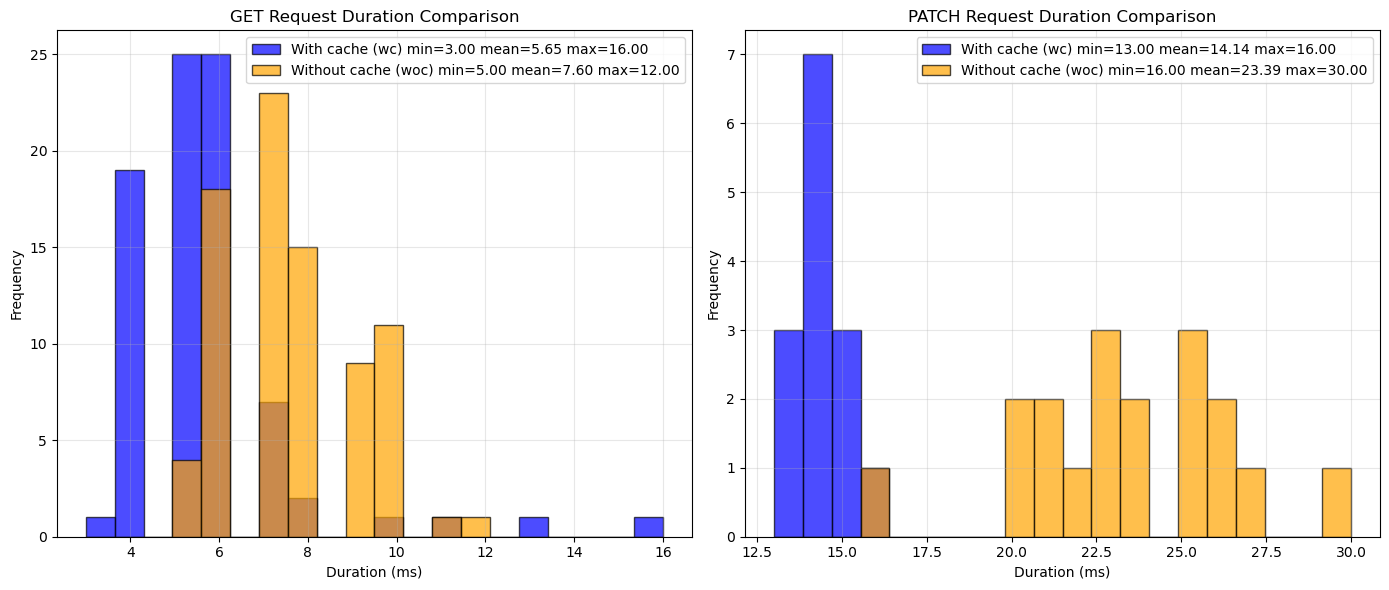

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Гистограмма для GET
if len(get_stats_wc) > 0 and len(get_stats_woc) > 0:
    get_wc = get_stats_data[0]
    get_woc = get_stats_data[1]
    bins = np.histogram_bin_edges(np.concatenate([get_stats_wc, get_stats_woc]), bins=20)
    axes[0].hist(get_stats_wc, bins=bins, alpha=0.7,
                label=f'With cache (wc) min={get_wc["min"]:.2f} mean={get_wc["mean"]:.2f} max={get_wc["max"]:.2f}',
                color='blue', edgecolor='black'
            )
    axes[0].hist(get_stats_woc, bins=bins, alpha=0.7,
                label=f'Without cache (woc) min={get_woc["min"]:.2f} mean={get_woc["mean"]:.2f} max={get_woc["max"]:.2f}',
                color='orange', edgecolor='black'
            )
    axes[0].set_xlabel('Duration (ms)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('GET Request Duration Comparison')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No data available', horizontalalignment='center', 
                 verticalalignment='center', transform=axes[0].transAxes)

# Гистограмма для PATCH
if len(patch_stats_wc) > 0 and len(patch_stats_woc) > 0:
    patch_wc = patch_stats_data[0]
    patch_woc = patch_stats_data[1]
    bins = np.histogram_bin_edges(np.concatenate([patch_stats_wc, patch_stats_woc]), bins=20)
    axes[1].hist(patch_stats_wc, bins=bins, alpha=0.7,
                label=f'With cache (wc) min={patch_wc["min"]:.2f} mean={patch_wc["mean"]:.2f} max={patch_wc["max"]:.2f}',
                color='blue', edgecolor='black'
            )
    axes[1].hist(patch_stats_woc, bins=bins, alpha=0.7,
                label=f'Without cache (woc) min={patch_woc["min"]:.2f} mean={patch_woc["mean"]:.2f} max={patch_woc["max"]:.2f}',
                color='orange', edgecolor='black'
            )
    axes[1].set_xlabel('Duration (ms)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('PATCH Request Duration Comparison')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No data available', horizontalalignment='center', 
                 verticalalignment='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('net_stats.png')
plt.show()
